# R2-Dreamer: JAX vs PyTorch — Paper Benchmark

Three-way comparison on **Crafter** replay data:

| Variant | Framework | Rep Loss |
|---|---|---|
| **DreamerV3 (PyTorch)** | PyTorch | Reconstruction (decoder) |
| **R2-Dreamer (PyTorch)** | PyTorch | Barlow Twins |
| **R2-Dreamer (JAX)** | JAX/Flax | Barlow Twins |

**Protocol:** Pre-collect 10 000 Crafter steps into a shared replay buffer, then
train each variant for 4 000 steps on identical batches. Measure wall-clock
time, peak GPU memory, and loss curves.

In [1]:
import os, sys, time, copy, gc, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 12, "figure.dpi": 120})
warnings.filterwarnings("ignore")

# Project root
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# External R2-Dreamer repo (PyTorch)
EXT = os.path.join(ROOT, "external", "r2dreamer")
if EXT not in sys.path:
    sys.path.insert(0, EXT)

# Config
NUM_COLLECT  = 10_000   # Crafter env steps to pre-collect
WARMUP_STEPS = 3        # JIT warmup (excluded from timing)
TRAIN_STEPS  = 4_000    # Timed training steps
BATCH_SIZE   = 16
SEQ_LEN      = 64
NUM_ACTIONS  = 17       # Crafter
OBS_SHAPE_HWC = (64, 64, 3)
OBS_SHAPE_CHW = (3, 64, 64)

print(f"Root: {ROOT}")
print(f"External: {EXT}")

Root: /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA
External: /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/external/r2dreamer


## 1. Collect Crafter Replay Data

We collect transitions using random actions to build a shared replay buffer.

In [2]:
from modules.envs.crafter import CrafterEnv

env = CrafterEnv(size=(64, 64), seed=42)

# Collect transitions: each is {image: CHW uint8, reward, done, is_first}
transitions = []
obs = env.reset()
for step in range(NUM_COLLECT):
    action = np.random.randint(0, NUM_ACTIONS)
    next_obs = env.step(action)
    transitions.append({
        "image_chw": obs["image"].copy(),          # (C,H,W) uint8
        "image_hwc": obs["image"].transpose(1, 2, 0).copy(),  # (H,W,C) uint8
        "action": action,
        "reward": next_obs["reward"],
        "is_first": obs["is_first"],
        "is_last": next_obs["done"],
        "is_terminal": next_obs["done"],
    })
    if next_obs["done"]:
        obs = env.reset()
    else:
        obs = next_obs

env.close()
print(f"Collected {len(transitions)} transitions")
print(f"Sample obs shape CHW: {transitions[0]['image_chw'].shape}")
print(f"Sample obs shape HWC: {transitions[0]['image_hwc'].shape}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Collected 10000 transitions
Sample obs shape CHW: (3, 64, 64)
Sample obs shape HWC: (64, 64, 3)


In [3]:
SEED = 42

def precompute_batch_starts(num_steps, batch_size, seq_len, num_transitions, seed):
    """Pre-generate all batch start indices so every variant trains on identical data."""
    rng = np.random.RandomState(seed)
    max_start = num_transitions - seq_len
    return [rng.randint(0, max_start, size=batch_size) for _ in range(num_steps)]

# Pre-generate starts for warmup + training (same for all 3 variants)
all_starts = precompute_batch_starts(
    WARMUP_STEPS + TRAIN_STEPS, BATCH_SIZE, SEQ_LEN, len(transitions), seed=SEED
)
print(f"Pre-generated {len(all_starts)} batch start arrays (seed={SEED})")


def make_batch_jax(transitions, starts):
    """Build a JAX batch from pre-determined start indices: (B, T, C, H, W) float32."""
    import jax.numpy as jnp
    B, T = len(starts), SEQ_LEN
    obs = np.zeros((B, T, *OBS_SHAPE_CHW), dtype=np.float32)
    actions = np.zeros((B, T, NUM_ACTIONS), dtype=np.float32)
    rewards = np.zeros((B, T), dtype=np.float32)
    is_first = np.zeros((B, T), dtype=np.float32)
    is_last = np.zeros((B, T), dtype=np.float32)
    is_terminal = np.zeros((B, T), dtype=np.float32)
    for i, s in enumerate(starts):
        for t in range(T):
            tr = transitions[s + t]
            obs[i, t] = tr["image_chw"].astype(np.float32) / 255.0
            actions[i, t, tr["action"]] = 1.0
            rewards[i, t] = tr["reward"]
            is_first[i, t] = float(tr["is_first"])
            is_last[i, t] = float(tr["is_last"])
            is_terminal[i, t] = float(tr["is_terminal"])
    return {
        "obs": jnp.array(obs), "actions": jnp.array(actions),
        "rewards": jnp.array(rewards), "is_first": jnp.array(is_first),
        "is_last": jnp.array(is_last), "is_terminal": jnp.array(is_terminal),
    }


def make_batch_torch(transitions, starts, device="cuda"):
    """Build a PyTorch TensorDict batch from pre-determined start indices."""
    import torch
    from tensordict import TensorDict
    B, T = len(starts), SEQ_LEN
    obs = np.zeros((B, T, *OBS_SHAPE_HWC), dtype=np.uint8)
    actions = np.zeros((B, T, NUM_ACTIONS), dtype=np.float32)
    rewards = np.zeros((B, T, 1), dtype=np.float32)
    is_first = np.zeros((B, T, 1), dtype=np.float32)
    is_last = np.zeros((B, T, 1), dtype=np.float32)
    is_terminal = np.zeros((B, T, 1), dtype=np.float32)
    for i, s in enumerate(starts):
        for t in range(T):
            tr = transitions[s + t]
            obs[i, t] = tr["image_hwc"]
            actions[i, t, tr["action"]] = 1.0
            rewards[i, t, 0] = tr["reward"]
            is_first[i, t, 0] = float(tr["is_first"])
            is_last[i, t, 0] = float(tr["is_last"])
            is_terminal[i, t, 0] = float(tr["is_terminal"])
    return TensorDict({
        "image": torch.tensor(obs, device=device),
        "action": torch.tensor(actions, device=device),
        "reward": torch.tensor(rewards, device=device),
        "is_first": torch.tensor(is_first, dtype=torch.bool, device=device),
        "is_last": torch.tensor(is_last, dtype=torch.bool, device=device),
        "is_terminal": torch.tensor(is_terminal, dtype=torch.bool, device=device),
    }, batch_size=(B, T))


print("Deterministic batch builders ready.")

Pre-generated 4003 batch start arrays (seed=42)
Deterministic batch builders ready.


## 2. GPU Info

In [4]:
import torch
import jax

print(f"PyTorch {torch.__version__}")
print(f"JAX     {jax.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"JAX devices: {jax.devices()}")

PyTorch 2.10.0+cu128
JAX     0.6.2
GPU: NVIDIA H100
VRAM: 100.0 GB


JAX devices: [CudaDevice(id=0)]


## 3. R2-Dreamer (JAX) Benchmark

In [5]:
import jax
import jax.numpy as jnp
from modules.r2dreamer.config import R2DreamerConfig
from modules.r2dreamer.agent import R2DreamerAgent

cfg_jax = R2DreamerConfig(
    obs_shape=OBS_SHAPE_CHW,
    num_actions=NUM_ACTIONS,
    batch_size=BATCH_SIZE,
    seq_len=SEQ_LEN,
)

rng = jax.random.PRNGKey(SEED)
rng, init_key = jax.random.split(rng)
agent_jax = R2DreamerAgent(cfg_jax, init_key)

param_count_jax = sum(x.size for x in jax.tree.leaves(agent_jax.params))
print(f"JAX R2-Dreamer params: {param_count_jax:,}")

# Warmup (uses first WARMUP_STEPS from all_starts)
print(f"Warming up ({WARMUP_STEPS} steps)...")
for i in range(WARMUP_STEPS):
    rng, k = jax.random.split(rng)
    batch = make_batch_jax(transitions, all_starts[i])
    _ = agent_jax.train_step(batch, k)
    jax.block_until_ready(agent_jax.params)
print("Warmup done.")

# Timed training (uses remaining starts)
jax_metrics_history = []
jax_step_times = []
print(f"Training {TRAIN_STEPS} steps (seed={SEED})...")
for i in range(TRAIN_STEPS):
    rng, k = jax.random.split(rng)
    batch = make_batch_jax(transitions, all_starts[WARMUP_STEPS + i])
    t0 = time.perf_counter()
    metrics = agent_jax.train_step(batch, k)
    jax.block_until_ready(agent_jax.params)
    t1 = time.perf_counter()
    jax_step_times.append(t1 - t0)
    jax_metrics_history.append(metrics)
    if (i + 1) % 500 == 0:
        print(f"  step {i+1}/{TRAIN_STEPS} | loss={metrics.get('total_loss', 0):.3f} | {(t1-t0)*1000:.1f} ms")

jax_peak_mem = jax.devices()[0].memory_stats()["peak_bytes_in_use"] / 1e9

jax_times_arr = np.array(jax_step_times)
median_t = np.median(jax_times_arr)
mask = jax_times_arr < 5 * median_t
jax_mean_step = np.mean(jax_times_arr[mask]) * 1000
jax_std_step = np.std(jax_times_arr[mask]) * 1000
jax_total_time = sum(jax_step_times)
n_outliers = int((~mask).sum())

print(f"\nJAX R2-Dreamer: {jax_mean_step:.1f} +/- {jax_std_step:.1f} ms/step")
print(f"Peak GPU memory: {jax_peak_mem:.2f} GB")
print(f"Total time: {jax_total_time:.1f} s")
if n_outliers > 0:
    print(f"({n_outliers} timing outliers filtered from mean/std)")

# Keep agent alive for evaluation later
agent_jax_trained = agent_jax
print("Agent kept for evaluation.")

JAX R2-Dreamer params: 11,845,648
Warming up (3 steps)...


2026-03-30 08:20:48.149986: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-30 08:20:48.151752: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-30 08:20:48.152416: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


2026-03-30 08:21:00.973418: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.5 = (f32[48,5,5,32]{3,2,1,0}, u8[0]{0}) custom-call(%multiply.2663, %scatter.2), window={size=5x5 pad=2_2x2_2}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_name="jit(_train_step)/jit(main)/transpose(jvp(R2Encoder))/conv1/conv_general_dilated" source_file="/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/.venv/lib/python3.10/site-packages/flax/linen/linear.py" source_line=695}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...


2026-03-30 08:21:04.877241: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.903941885s
Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.5 = (f32[48,5,5,32]{3,2,1,0}, u8[0]{0}) custom-call(%multiply.2663, %scatter.2), window={size=5x5 pad=2_2x2_2}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_name="jit(_train_step)/jit(main)/transpose(jvp(R2Encoder))/conv1/conv_general_dilated" source_file="/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/.venv/lib/python3.10/site-packages/flax/linen/linear.py" source_line=695}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...


2026-03-30 08:21:06.070166: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.6 = (f32[64,5,5,48]{3,2,1,0}, u8[0]{0}) custom-call(%multiply.2665, %scatter.1), window={size=5x5 pad=2_2x2_2}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_name="jit(_train_step)/jit(main)/transpose(jvp(R2Encoder))/conv2/conv_general_dilated" source_file="/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/.venv/lib/python3.10/site-packages/flax/linen/linear.py" source_line=695}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...


...

  step 2000/4000 | loss=7.901 | 48.2 ms


  step 2500/4000 | loss=8.085 | 48.0 ms


  step 3000/4000 | loss=7.669 | 47.6 ms


  step 3500/4000 | loss=7.599 | 48.4 ms


  step 4000/4000 | loss=7.284 | 47.4 ms

JAX R2-Dreamer: 47.7 +/- 0.8 ms/step
Peak GPU memory: 6.76 GB
Total time: 190.6 s
Agent kept for evaluation.


## 4. PyTorch Setup

The external R2-Dreamer uses Hydra for configuration. We construct the config
programmatically using `omegaconf` to avoid launching a Hydra job.

In [6]:
import torch
from omegaconf import OmegaConf

torch.set_float32_matmul_precision("high")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Build the config manually with all values resolved (no ${} interpolations).
# Values taken from configs/model/_base_.yaml + configs/model/size12M.yaml
# size12M: deter=2048, hidden=256, discrete=16, depth=16, units=256
model_cfg = OmegaConf.create({
    "act_entropy": 3e-4,
    "kl_free": 1.0,
    "imag_horizon": 15,
    "horizon": 333,
    "lamb": 0.95,
    "compile": False,  # disable torch.compile for fair comparison
    "log_grads": False,
    "device": DEVICE,
    "rep_loss": "r2dreamer",

    "lr": 4e-5,
    "agc": 0.3,
    "pmin": 1e-3,
    "eps": 1e-20,
    "beta1": 0.9,
    "beta2": 0.999,
    "warmup": 1000,
    "slow_target_update": 1,
    "slow_target_fraction": 0.02,

    "loss_scales": {
        "barlow": 0.05, "infonce": 1.0, "recon": 1.0,
        "rew": 1.0, "con": 1.0, "dyn": 1.0, "rep": 0.1,
        "policy": 1.0, "value": 1.0, "repval": 0.3,
        "swav": 1.0, "temp": 1.0, "norm": 1.0,
    },

    "r2dreamer": {"lambd": 5e-4},

    "rssm": {
        "stoch": 32, "deter": 2048, "hidden": 256, "discrete": 16,
        "img_layers": 2, "obs_layers": 1, "dyn_layers": 1, "blocks": 8,
        "act": "SiLU", "norm": True, "unimix_ratio": 0.01,
        "initial": "learned", "device": DEVICE,
    },

    "encoder": {
        "mlp_keys": "$^",
        "cnn_keys": "image",
        "mlp": {
            "shape": None, "layers": 3, "units": 256, "act": "SiLU",
            "norm": True, "device": DEVICE, "outscale": None,
            "symlog_inputs": True, "name": "mlp_encoder",
        },
        "cnn": {
            "act": "SiLU", "norm": True, "kernel_size": 5,
            "minres": 4, "depth": 16, "mults": [2, 3, 4, 4],
        },
    },

    "decoder": {
        "mlp_keys": "$^",
        "cnn_keys": "image",
        "mlp_dist": {"name": "symlog_mse"},
        "cnn_dist": {"name": "mse"},
        "mlp": {
            "shape": None, "layers": 3, "units": 256, "act": "SiLU",
            "norm": True, "dist": {"name": "identity"}, "device": DEVICE,
            "outscale": 1.0, "symlog_inputs": False, "name": "mlp_decoder",
        },
        "cnn": {
            "depth": 16, "units": 256, "bspace": 8, "mults": [2, 3, 4, 4],
            "act": "SiLU", "norm": True, "kernel_size": 5, "minres": 4,
            "outscale": 1.0,
        },
    },

    "reward": {
        "shape": [255], "layers": 1, "units": 256, "act": "SiLU",
        "norm": True, "dist": {"name": "symexp_twohot", "bin_num": 255},
        "outscale": 0.0, "device": DEVICE, "symlog_inputs": False,
        "name": "reward",
    },

    "cont": {
        "shape": [1], "layers": 1, "units": 256, "act": "SiLU",
        "norm": True, "dist": {"name": "binary"},
        "outscale": 1.0, "device": DEVICE, "symlog_inputs": False,
        "name": "cont",
    },

    "actor": {
        "shape": None, "layers": 3, "units": 256, "act": "SiLU",
        "norm": True, "device": DEVICE,
        "dist": {
            "cont": {"name": "bounded_normal", "min_std": 0.1, "max_std": 1.0},
            "disc": {"name": "onehot", "unimix_ratio": 0.01},
            "multi_disc": {"name": "multi_onehot", "unimix_ratio": 0.01},
        },
        "outscale": 0.01, "symlog_inputs": False, "name": "actor",
    },

    "critic": {
        "shape": [255], "layers": 3, "units": 256, "act": "SiLU",
        "norm": True, "device": DEVICE,
        "dist": {"name": "symexp_twohot", "bin_num": 255},
        "outscale": 0.0, "symlog_inputs": False, "name": "value",
    },
})

print("Model config built (all values resolved, no interpolations).")
print(f"  deter={model_cfg.rssm.deter}, hidden={model_cfg.rssm.hidden}, discrete={model_cfg.rssm.discrete}")
print(f"  rep_loss={model_cfg.rep_loss}")

Model config built (all values resolved, no interpolations).
  deter=2048, hidden=256, discrete=16
  rep_loss=r2dreamer


In [7]:
import gymnasium as gym

def make_crafter_spaces():
    """Create obs_space and act_space matching external R2-Dreamer expectations."""
    obs_space = gym.spaces.Dict({
        "image": gym.spaces.Box(0, 255, OBS_SHAPE_HWC, dtype=np.uint8),
    })
    act_space = gym.spaces.Box(low=0, high=1, shape=(NUM_ACTIONS,), dtype=np.float32)
    act_space.discrete = True
    return obs_space, act_space

obs_space, act_space = make_crafter_spaces()
print(f"obs_space: {obs_space}")
print(f"act_space: {act_space} (discrete={act_space.discrete})")

obs_space: Dict('image': Box(0, 255, (64, 64, 3), uint8))
act_space: Box(0.0, 1.0, (17,), float32) (discrete=True)


## 5. R2-Dreamer (PyTorch) Benchmark

In [8]:
from dreamer import Dreamer

# R2-Dreamer mode (Barlow Twins)
r2_cfg = model_cfg.copy()
OmegaConf.update(r2_cfg, "rep_loss", "r2dreamer")

obs_space, act_space = make_crafter_spaces()
agent_r2_pt = Dreamer(r2_cfg, obs_space, act_space).to(DEVICE)

param_count_r2_pt = sum(p.numel() for p in agent_r2_pt._named_params.values())
print(f"\nPyTorch R2-Dreamer params (optimizer): {param_count_r2_pt:,}")

def train_step_pytorch(agent, data, initial):
    """One training step for the external PyTorch agent, bypassing replay buffer."""
    from torch.amp import autocast
    torch.compiler.cudagraph_mark_step_begin()
    p_data = agent.preprocess(data)
    agent._update_slow_target()
    metrics = {}
    with autocast(device_type=agent.device.type, dtype=torch.float16):
        (stoch, deter), mets = agent._cal_grad(p_data, initial)
    agent._scaler.unscale_(agent._optimizer)
    agent._agc(agent._named_params.values())
    agent._scaler.step(agent._optimizer)
    agent._scaler.update()
    agent._scheduler.step()
    agent._optimizer.zero_grad(set_to_none=True)
    metrics.update(mets)
    return metrics, stoch, deter

# Warmup (same batch starts)
print(f"Warming up ({WARMUP_STEPS} steps)...")
for i in range(WARMUP_STEPS):
    data = make_batch_torch(transitions, all_starts[i], DEVICE)
    stoch0 = torch.zeros(BATCH_SIZE, r2_cfg.rssm.stoch, r2_cfg.rssm.discrete, device=DEVICE)
    deter0 = torch.zeros(BATCH_SIZE, r2_cfg.rssm.deter, device=DEVICE)
    _ = train_step_pytorch(agent_r2_pt, data, (stoch0, deter0))
print("Warmup done.")

torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

# Timed training (same batch starts as JAX)
r2_pt_metrics_history = []
r2_pt_step_times = []
print(f"Training {TRAIN_STEPS} steps (seed={SEED})...")
for i in range(TRAIN_STEPS):
    data = make_batch_torch(transitions, all_starts[WARMUP_STEPS + i], DEVICE)
    stoch0 = torch.zeros(BATCH_SIZE, r2_cfg.rssm.stoch, r2_cfg.rssm.discrete, device=DEVICE)
    deter0 = torch.zeros(BATCH_SIZE, r2_cfg.rssm.deter, device=DEVICE)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    mets, _, _ = train_step_pytorch(agent_r2_pt, data, (stoch0, deter0))
    torch.cuda.synchronize()
    t1 = time.perf_counter()
    r2_pt_step_times.append(t1 - t0)
    r2_pt_metrics_history.append({k: float(v) if isinstance(v, torch.Tensor) else float(v) for k, v in mets.items()})
    if (i + 1) % 500 == 0:
        loss = mets.get("opt/loss", 0)
        loss_val = float(loss) if isinstance(loss, torch.Tensor) else float(loss)
        print(f"  step {i+1}/{TRAIN_STEPS} | loss={loss_val:.3f} | {(t1-t0)*1000:.1f} ms")

r2_pt_peak_mem = torch.cuda.max_memory_allocated() / 1e9
r2_pt_total_time = sum(r2_pt_step_times)
r2_pt_mean_step = np.mean(r2_pt_step_times) * 1000
r2_pt_std_step = np.std(r2_pt_step_times) * 1000

print(f"\nPyTorch R2-Dreamer: {r2_pt_mean_step:.1f} +/- {r2_pt_std_step:.1f} ms/step")
print(f"Peak GPU memory: {r2_pt_peak_mem:.2f} GB")
print(f"Total time: {r2_pt_total_time:.1f} s")

# Keep agent alive for evaluation
agent_r2_pt_trained = agent_r2_pt
print("Agent kept for evaluation.")

Encoder CNN shapes: {'image': (64, 64, 3)}
Encoder MLP shapes: {}
     5,982,464: rssm
       792,337: actor
       853,503: value
       721,407: reward
       656,129: cont
       220,416: encoder
     2,621,440: projector
Optimizer has: 11847696 parameters.

PyTorch R2-Dreamer params (optimizer): 11,847,696
Warming up (3 steps)...


Warmup done.
Training 4000 steps (seed=42)...


  step 500/4000 | loss=27.410 | 280.5 ms


  step 1000/4000 | loss=14.020 | 280.1 ms


  step 1500/4000 | loss=13.405 | 281.1 ms


  step 2000/4000 | loss=13.120 | 281.3 ms


  step 2500/4000 | loss=13.223 | 281.0 ms


  step 3000/4000 | loss=11.875 | 281.3 ms


  step 3500/4000 | loss=10.930 | 281.0 ms


  step 4000/4000 | loss=10.985 | 281.5 ms

PyTorch R2-Dreamer: 282.0 +/- 13.3 ms/step
Peak GPU memory: 2.90 GB
Total time: 1128.1 s
Agent kept for evaluation.


## 6. DreamerV3 (PyTorch) Benchmark

Same external repo, but with `rep_loss="dreamer"` which adds a decoder for
observation reconstruction.

In [9]:
# DreamerV3 mode (reconstruction loss)
dv3_cfg = model_cfg.copy()
OmegaConf.update(dv3_cfg, "rep_loss", "dreamer")

obs_space, act_space = make_crafter_spaces()
agent_dv3_pt = Dreamer(dv3_cfg, obs_space, act_space).to(DEVICE)

param_count_dv3_pt = sum(p.numel() for p in agent_dv3_pt._named_params.values())
print(f"PyTorch DreamerV3 params (optimizer): {param_count_dv3_pt:,}")

# Warmup (same batch starts)
print(f"Warming up ({WARMUP_STEPS} steps)...")
for i in range(WARMUP_STEPS):
    data = make_batch_torch(transitions, all_starts[i], DEVICE)
    stoch0 = torch.zeros(BATCH_SIZE, dv3_cfg.rssm.stoch, dv3_cfg.rssm.discrete, device=DEVICE)
    deter0 = torch.zeros(BATCH_SIZE, dv3_cfg.rssm.deter, device=DEVICE)
    _ = train_step_pytorch(agent_dv3_pt, data, (stoch0, deter0))
print("Warmup done.")

torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

# Timed training (same batch starts as JAX and R2-PT)
dv3_pt_metrics_history = []
dv3_pt_step_times = []
print(f"Training {TRAIN_STEPS} steps (seed={SEED})...")
for i in range(TRAIN_STEPS):
    data = make_batch_torch(transitions, all_starts[WARMUP_STEPS + i], DEVICE)
    stoch0 = torch.zeros(BATCH_SIZE, dv3_cfg.rssm.stoch, dv3_cfg.rssm.discrete, device=DEVICE)
    deter0 = torch.zeros(BATCH_SIZE, dv3_cfg.rssm.deter, device=DEVICE)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    mets, _, _ = train_step_pytorch(agent_dv3_pt, data, (stoch0, deter0))
    torch.cuda.synchronize()
    t1 = time.perf_counter()
    dv3_pt_step_times.append(t1 - t0)
    dv3_pt_metrics_history.append({k: float(v) if isinstance(v, torch.Tensor) else float(v) for k, v in mets.items()})
    if (i + 1) % 500 == 0:
        loss = mets.get("opt/loss", 0)
        loss_val = float(loss) if isinstance(loss, torch.Tensor) else float(loss)
        print(f"  step {i+1}/{TRAIN_STEPS} | loss={loss_val:.3f} | {(t1-t0)*1000:.1f} ms")

dv3_pt_peak_mem = torch.cuda.max_memory_allocated() / 1e9
dv3_pt_total_time = sum(dv3_pt_step_times)
dv3_pt_mean_step = np.mean(dv3_pt_step_times) * 1000
dv3_pt_std_step = np.std(dv3_pt_step_times) * 1000

print(f"\nPyTorch DreamerV3: {dv3_pt_mean_step:.1f} +/- {dv3_pt_std_step:.1f} ms/step")
print(f"Peak GPU memory: {dv3_pt_peak_mem:.2f} GB")
print(f"Total time: {dv3_pt_total_time:.1f} s")

# Keep agent alive for evaluation
agent_dv3_pt_trained = agent_dv3_pt
print("Agent kept for evaluation.")

Encoder CNN shapes: {'image': (64, 64, 3)}
Encoder MLP shapes: {}
Decoder CNN shapes: {'image': (64, 64, 3)}
Decoder MLP shapes: {}
     5,982,464: rssm
       792,337: actor
       853,503: value
       721,407: reward
       656,129: cont
       220,416: encoder
     1,272,003: decoder
Optimizer has: 10498259 parameters.
PyTorch DreamerV3 params (optimizer): 10,498,259
Warming up (3 steps)...


Warmup done.
Training 4000 steps (seed=42)...


  step 500/4000 | loss=178.356 | 293.0 ms


  step 1000/4000 | loss=117.307 | 291.5 ms


  step 1500/4000 | loss=107.002 | 291.4 ms


  step 2000/4000 | loss=92.646 | 291.4 ms


  step 2500/4000 | loss=78.674 | 296.9 ms


  step 3000/4000 | loss=65.838 | 290.6 ms


  step 3500/4000 | loss=62.344 | 291.3 ms


  step 4000/4000 | loss=55.774 | 290.9 ms

PyTorch DreamerV3: 292.5 +/- 16.2 ms/step
Peak GPU memory: 4.44 GB
Total time: 1169.8 s
Agent kept for evaluation.


## 7. Results

In [10]:
# Collect results
results = {
    "R2-Dreamer (JAX)": {
        "mean_step_ms": jax_mean_step,
        "std_step_ms": jax_std_step,
        "steps_per_sec": TRAIN_STEPS / jax_total_time,
        "peak_gpu_gb": jax_peak_mem,
        "total_time_s": jax_total_time,
        "params": param_count_jax,
    },
    "R2-Dreamer (PyTorch)": {
        "mean_step_ms": r2_pt_mean_step,
        "std_step_ms": r2_pt_std_step,
        "steps_per_sec": TRAIN_STEPS / r2_pt_total_time,
        "peak_gpu_gb": r2_pt_peak_mem,
        "total_time_s": r2_pt_total_time,
        "params": param_count_r2_pt,
    },
    "DreamerV3 (PyTorch)": {
        "mean_step_ms": dv3_pt_mean_step,
        "std_step_ms": dv3_pt_std_step,
        "steps_per_sec": TRAIN_STEPS / dv3_pt_total_time,
        "peak_gpu_gb": dv3_pt_peak_mem,
        "total_time_s": dv3_pt_total_time,
        "params": param_count_dv3_pt,
    },
}

# Print summary table
print(f"{'Variant':<25} {'Params':>10} {'ms/step':>10} {'steps/s':>10} {'GPU (GB)':>10} {'Total (s)':>10}")
print("-" * 80)
for name, r in results.items():
    print(f"{name:<25} {r['params']:>10,} {r['mean_step_ms']:>8.1f}ms {r['steps_per_sec']:>10.1f} {r['peak_gpu_gb']:>8.2f}GB {r['total_time_s']:>9.1f}s")

# Save results
os.makedirs(os.path.join(ROOT, "output", "comparison"), exist_ok=True)
with open(os.path.join(ROOT, "output", "comparison", "r2dreamer_jax_vs_pytorch.json"), "w") as f:
    json.dump(results, f, indent=2)
print("\nResults saved to output/comparison/r2dreamer_jax_vs_pytorch.json")

Variant                       Params    ms/step    steps/s   GPU (GB)  Total (s)
--------------------------------------------------------------------------------
R2-Dreamer (JAX)          11,845,648     47.7ms       21.0     6.76GB     190.6s
R2-Dreamer (PyTorch)      11,847,696    282.0ms        3.5     2.90GB    1128.1s
DreamerV3 (PyTorch)       10,498,259    292.5ms        3.4     4.44GB    1169.8s

Results saved to output/comparison/r2dreamer_jax_vs_pytorch.json


## 8. Performance Figures

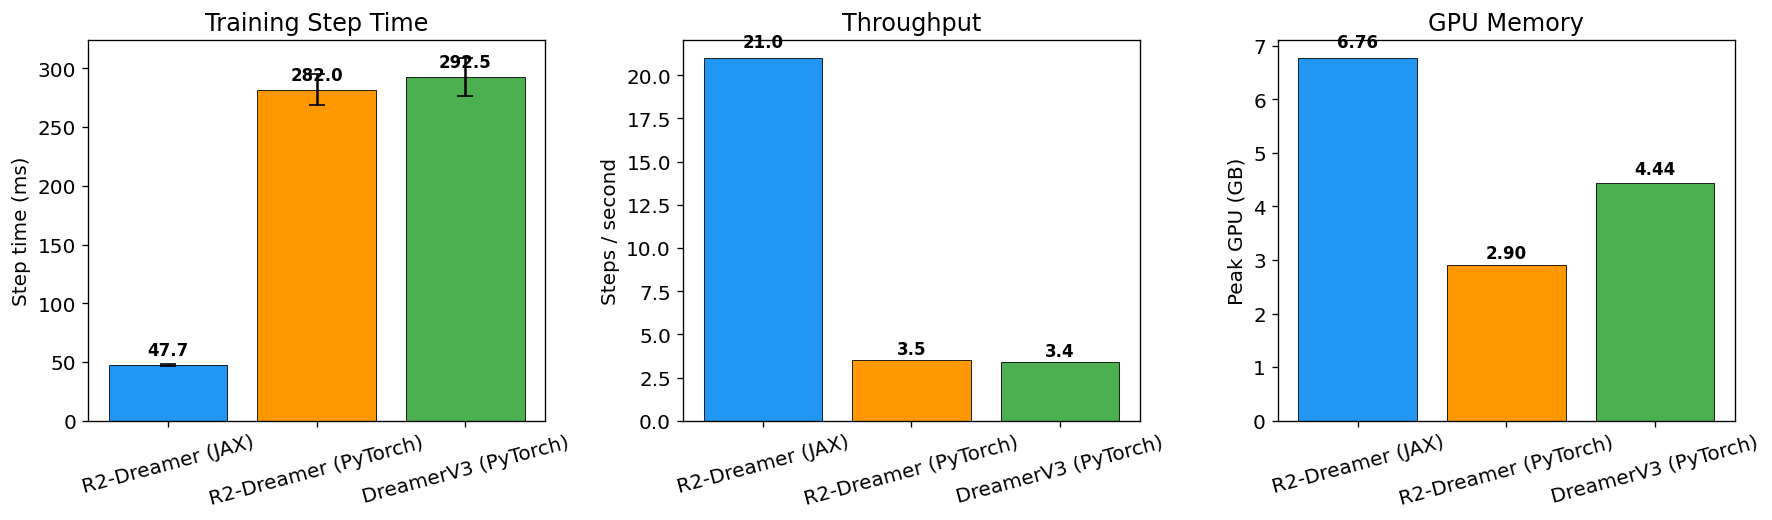

Saved: output/comparison/r2dreamer_performance.{pdf,png}


In [11]:
labels = list(results.keys())
colors = ["#2196F3", "#FF9800", "#4CAF50"]  # Blue=JAX, Orange=R2-PT, Green=DV3-PT

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# --- Step time ---
ax = axes[0]
means = [results[l]["mean_step_ms"] for l in labels]
stds = [results[l]["std_step_ms"] for l in labels]
bars = ax.bar(labels, means, yerr=stds, color=colors, capsize=5, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Step time (ms)")
ax.set_title("Training Step Time")
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds)*0.3,
            f"{m:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.tick_params(axis="x", rotation=15)

# --- Steps per second ---
ax = axes[1]
sps = [results[l]["steps_per_sec"] for l in labels]
bars = ax.bar(labels, sps, color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Steps / second")
ax.set_title("Throughput")
for bar, s in zip(bars, sps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
            f"{s:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.tick_params(axis="x", rotation=15)

# --- Peak GPU memory ---
ax = axes[2]
mems = [results[l]["peak_gpu_gb"] for l in labels]
bars = ax.bar(labels, mems, color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Peak GPU (GB)")
ax.set_title("GPU Memory")
for bar, m in zip(bars, mems):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
            f"{m:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
fig.savefig(os.path.join(ROOT, "output", "comparison", "r2dreamer_performance.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(ROOT, "output", "comparison", "r2dreamer_performance.png"), bbox_inches="tight", dpi=200)
plt.show()
print("Saved: output/comparison/r2dreamer_performance.{pdf,png}")

## 9. Loss Curves

Compare loss convergence across all three variants to verify that the JAX
implementation produces comparable training dynamics.

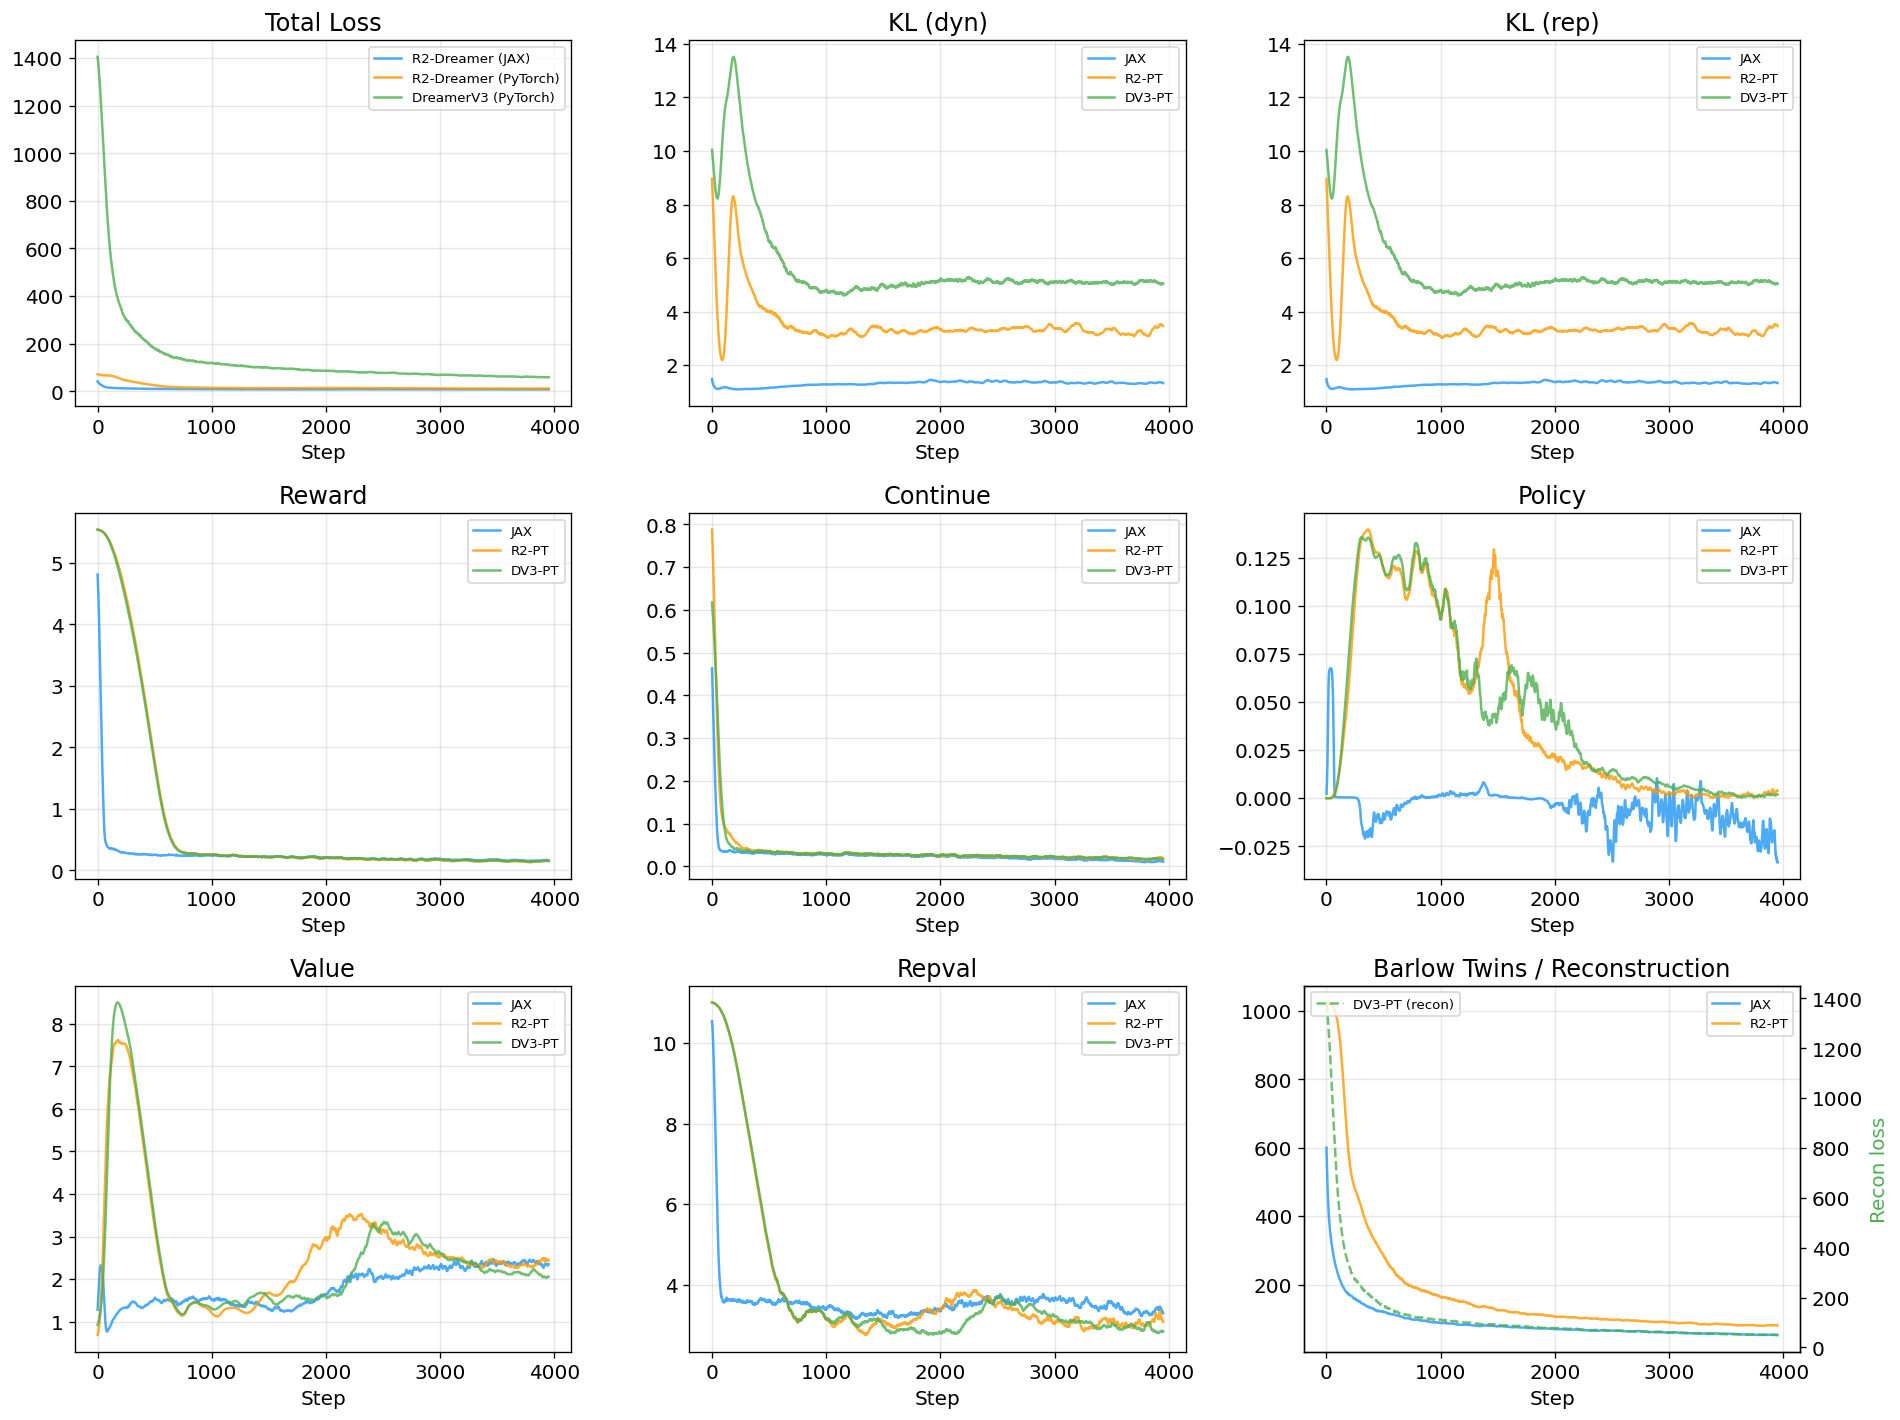

Saved: output/comparison/r2dreamer_losses.{pdf,png}


In [12]:
def smooth(values, window=50):
    """Simple moving average."""
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


def extract_loss(history, key):
    """Extract a loss series, trying multiple key patterns."""
    vals = []
    for m in history:
        # Try exact key, then with loss/ prefix
        v = m.get(key, m.get(f"loss/{key}", None))
        if v is not None:
            vals.append(float(v))
        else:
            vals.append(float("nan"))
    return np.array(vals)


# Map our JAX metric names to PyTorch metric names
shared_losses = [
    ("KL (dyn)",      "loss/dyn",    "loss/dyn",    "loss/dyn"),
    ("KL (rep)",      "loss/rep",    "loss/rep",    "loss/rep"),
    ("Reward",        "loss/rew",    "loss/rew",    "loss/rew"),
    ("Continue",      "loss/con",    "loss/con",    "loss/con"),
    ("Policy",        "loss/policy", "loss/policy", "loss/policy"),
    ("Value",         "loss/value",  "loss/value",  "loss/value"),
    ("Repval",        "loss/repval", "loss/repval", "loss/repval"),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

# Total loss
ax = axes[0]
jax_total = extract_loss(jax_metrics_history, "total_loss")
r2_total = extract_loss(r2_pt_metrics_history, "opt/loss")
dv3_total = extract_loss(dv3_pt_metrics_history, "opt/loss")
ax.plot(smooth(jax_total), label="R2-Dreamer (JAX)", color=colors[0], alpha=0.8)
ax.plot(smooth(r2_total), label="R2-Dreamer (PyTorch)", color=colors[1], alpha=0.8)
ax.plot(smooth(dv3_total), label="DreamerV3 (PyTorch)", color=colors[2], alpha=0.8)
ax.set_title("Total Loss")
ax.set_xlabel("Step")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Shared losses
for idx, (name, jax_key, r2_key, dv3_key) in enumerate(shared_losses):
    ax = axes[idx + 1]
    jax_vals = extract_loss(jax_metrics_history, jax_key)
    r2_vals = extract_loss(r2_pt_metrics_history, r2_key)
    dv3_vals = extract_loss(dv3_pt_metrics_history, dv3_key)
    if not np.all(np.isnan(jax_vals)):
        ax.plot(smooth(jax_vals), label="JAX", color=colors[0], alpha=0.8)
    if not np.all(np.isnan(r2_vals)):
        ax.plot(smooth(r2_vals), label="R2-PT", color=colors[1], alpha=0.8)
    if not np.all(np.isnan(dv3_vals)):
        ax.plot(smooth(dv3_vals), label="DV3-PT", color=colors[2], alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel("Step")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Barlow Twins loss (only JAX + R2-PT have this)
ax = axes[8]
jax_barlow = extract_loss(jax_metrics_history, "loss/barlow")
r2_barlow = extract_loss(r2_pt_metrics_history, "loss/barlow")
if not np.all(np.isnan(jax_barlow)):
    ax.plot(smooth(jax_barlow), label="JAX", color=colors[0], alpha=0.8)
if not np.all(np.isnan(r2_barlow)):
    ax.plot(smooth(r2_barlow), label="R2-PT", color=colors[1], alpha=0.8)
# DreamerV3 has image reconstruction instead
dv3_recon = extract_loss(dv3_pt_metrics_history, "loss/image")
if not np.all(np.isnan(dv3_recon)):
    ax2 = ax.twinx()
    ax2.plot(smooth(dv3_recon), label="DV3-PT (recon)", color=colors[2], alpha=0.8, linestyle="--")
    ax2.set_ylabel("Recon loss", color=colors[2])
    ax2.legend(fontsize=8, loc="upper left")
ax.set_title("Barlow Twins / Reconstruction")
ax.set_xlabel("Step")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(ROOT, "output", "comparison", "r2dreamer_losses.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(ROOT, "output", "comparison", "r2dreamer_losses.png"), bbox_inches="tight", dpi=200)
plt.show()
print("Saved: output/comparison/r2dreamer_losses.{pdf,png}")

## 10. Summary Table (LaTeX)

In [13]:
# Compute speedup relative to PyTorch R2-Dreamer
speedup_jax = r2_pt_mean_step / jax_mean_step
speedup_dv3 = r2_pt_mean_step / dv3_pt_mean_step

print(f"JAX speedup over PyTorch R2-Dreamer: {speedup_jax:.2f}x")
print(f"DV3 relative to R2 PyTorch: {speedup_dv3:.2f}x")
print()

# LaTeX table
latex = r"""
\begin{table}[h]
\centering
\caption{Training performance comparison on Crafter (batch\_size=16, seq\_len=64, 4000 steps).}
\label{tab:r2dreamer-benchmark}
\begin{tabular}{lccccc}
\toprule
Variant & Params & ms/step & Steps/s & GPU (GB) & Speedup \\
\midrule
"""

for name, r in results.items():
    sp = r2_pt_mean_step / r["mean_step_ms"]
    latex += f"{name} & {r['params']:,} & {r['mean_step_ms']:.1f} $\\pm$ {r['std_step_ms']:.1f} & {r['steps_per_sec']:.1f} & {r['peak_gpu_gb']:.2f} & {sp:.2f}$\\times$ \\\\\n"

latex += r"""\bottomrule
\end{tabular}
\end{table}
"""

print(latex)

# Save LaTeX
with open(os.path.join(ROOT, "output", "comparison", "r2dreamer_benchmark_table.tex"), "w") as f:
    f.write(latex)
print("Saved: output/comparison/r2dreamer_benchmark_table.tex")

JAX speedup over PyTorch R2-Dreamer: 5.92x
DV3 relative to R2 PyTorch: 0.96x


\begin{table}[h]
\centering
\caption{Training performance comparison on Crafter (batch\_size=16, seq\_len=64, 4000 steps).}
\label{tab:r2dreamer-benchmark}
\begin{tabular}{lccccc}
\toprule
Variant & Params & ms/step & Steps/s & GPU (GB) & Speedup \\
\midrule
R2-Dreamer (JAX) & 11,845,648 & 47.7 $\pm$ 0.8 & 21.0 & 6.76 & 5.92$\times$ \\
R2-Dreamer (PyTorch) & 11,847,696 & 282.0 $\pm$ 13.3 & 3.5 & 2.90 & 1.00$\times$ \\
DreamerV3 (PyTorch) & 10,498,259 & 292.5 $\pm$ 16.2 & 3.4 & 4.44 & 0.96$\times$ \\
\bottomrule
\end{tabular}
\end{table}

Saved: output/comparison/r2dreamer_benchmark_table.tex


## 11. Policy Evaluation in Crafter

Run each trained agent's policy in Crafter to compare actual episode
rewards. After only 4000 training steps (on replay data, no environment
interaction), the policies are undertrained — but we can check whether
the two R2-Dreamer implementations produce comparable reward signals.

In [14]:
from tensordict import TensorDict

EVAL_EPISODES = 10
EVAL_MAX_STEPS = 500  # cap per episode


def eval_jax_agent(agent, env, num_episodes, max_steps, rng_key):
    """Evaluate JAX R2-Dreamer agent in Crafter."""
    episode_rewards = []
    episode_lengths = []
    for ep in range(num_episodes):
        obs = env.reset()
        total_reward = 0.0
        rng_key, ep_key = jax.random.split(rng_key)
        for step in range(max_steps):
            rng_key, act_key = jax.random.split(rng_key)
            action = agent.act(obs, act_key, training=False)
            next_obs = env.step(action)
            total_reward += next_obs["reward"]
            if next_obs["done"]:
                break
            obs = next_obs
        episode_rewards.append(total_reward)
        episode_lengths.append(step + 1)
    return episode_rewards, episode_lengths


def eval_pytorch_agent(agent, env, num_episodes, max_steps, device):
    """Evaluate PyTorch Dreamer agent in Crafter.

    The agent.act() method expects:
      obs: TensorDict with "image" (B, 1, H, W, C) uint8 and "is_first" (B, 1) bool
      state: TensorDict with "stoch" (B, S, K), "deter" (B, D), "prev_action" (B, A)
    It internally squeezes the time dim in the encoder, but obs_step expects (B, E).
    We bypass act() and call the components directly to avoid shape issues.
    """
    agent.eval()
    episode_rewards = []
    episode_lengths = []
    for ep in range(num_episodes):
        obs_dict = env.reset()
        # Initialize state
        stoch, deter = agent.rssm.initial(1)
        stoch = stoch.to(device)
        deter = deter.to(device)
        prev_action = torch.zeros(1, NUM_ACTIONS, device=device)
        total_reward = 0.0

        for step in range(max_steps):
            with torch.no_grad():
                # Prepare observation: CHW -> HWC, uint8 -> float32 / 255
                image_hwc = obs_dict["image"].transpose(1, 2, 0)  # CHW -> HWC
                image_t = torch.tensor(image_hwc[None], dtype=torch.float32, device=device) / 255.0  # (1, H, W, C)
                is_first = torch.tensor([obs_dict["is_first"]], dtype=torch.bool, device=device)  # (1,)

                # Encode: (1, H, W, C) -> need (1, 1, H, W, C) for MultiEncoder
                img_batch = {"image": image_t.unsqueeze(1)}  # (1, 1, H, W, C)
                embed = agent._frozen_encoder(img_batch)  # (1, 1, E)
                embed = embed.squeeze(1)  # (1, E)

                # RSSM posterior step
                stoch, deter, _ = agent._frozen_rssm.obs_step(stoch, deter, prev_action, embed, is_first)

                # Get features and sample action
                feat = agent._frozen_rssm.get_feat(stoch, deter)  # (1, F)
                action_dist = agent._frozen_actor(feat)
                action = action_dist.mode  # greedy: (1, A)
                prev_action = action

            action_int = int(action[0].argmax().cpu())
            next_obs = env.step(action_int)
            total_reward += next_obs["reward"]
            if next_obs["done"]:
                break
            obs_dict = next_obs

        episode_rewards.append(total_reward)
        episode_lengths.append(step + 1)
    agent.train()
    return episode_rewards, episode_lengths


eval_env = CrafterEnv(size=(64, 64), seed=123)

# Evaluate all three agents
print(f"Evaluating agents ({EVAL_EPISODES} episodes each, max {EVAL_MAX_STEPS} steps)...")
print()

rng_eval = jax.random.PRNGKey(123)
jax_rewards, jax_lengths = eval_jax_agent(
    agent_jax_trained, eval_env, EVAL_EPISODES, EVAL_MAX_STEPS, rng_eval
)
print(f"JAX R2-Dreamer:     reward={np.mean(jax_rewards):.2f} +/- {np.std(jax_rewards):.2f}  "
      f"len={np.mean(jax_lengths):.0f}")

r2_pt_rewards, r2_pt_lengths = eval_pytorch_agent(
    agent_r2_pt_trained, eval_env, EVAL_EPISODES, EVAL_MAX_STEPS, DEVICE
)
print(f"R2-Dreamer (PT):    reward={np.mean(r2_pt_rewards):.2f} +/- {np.std(r2_pt_rewards):.2f}  "
      f"len={np.mean(r2_pt_lengths):.0f}")

dv3_pt_rewards, dv3_pt_lengths = eval_pytorch_agent(
    agent_dv3_pt_trained, eval_env, EVAL_EPISODES, EVAL_MAX_STEPS, DEVICE
)
print(f"DreamerV3 (PT):     reward={np.mean(dv3_pt_rewards):.2f} +/- {np.std(dv3_pt_rewards):.2f}  "
      f"len={np.mean(dv3_pt_lengths):.0f}")

eval_env.close()

# Clean up all agents
del agent_jax_trained, agent_r2_pt_trained, agent_dv3_pt_trained
torch.cuda.empty_cache()
gc.collect()

Evaluating agents (10 episodes each, max 500 steps)...



JAX R2-Dreamer:     reward=0.80 +/- 1.19  len=165


R2-Dreamer (PT):    reward=1.90 +/- 0.87  len=196


DreamerV3 (PT):     reward=0.40 +/- 0.46  len=151


60

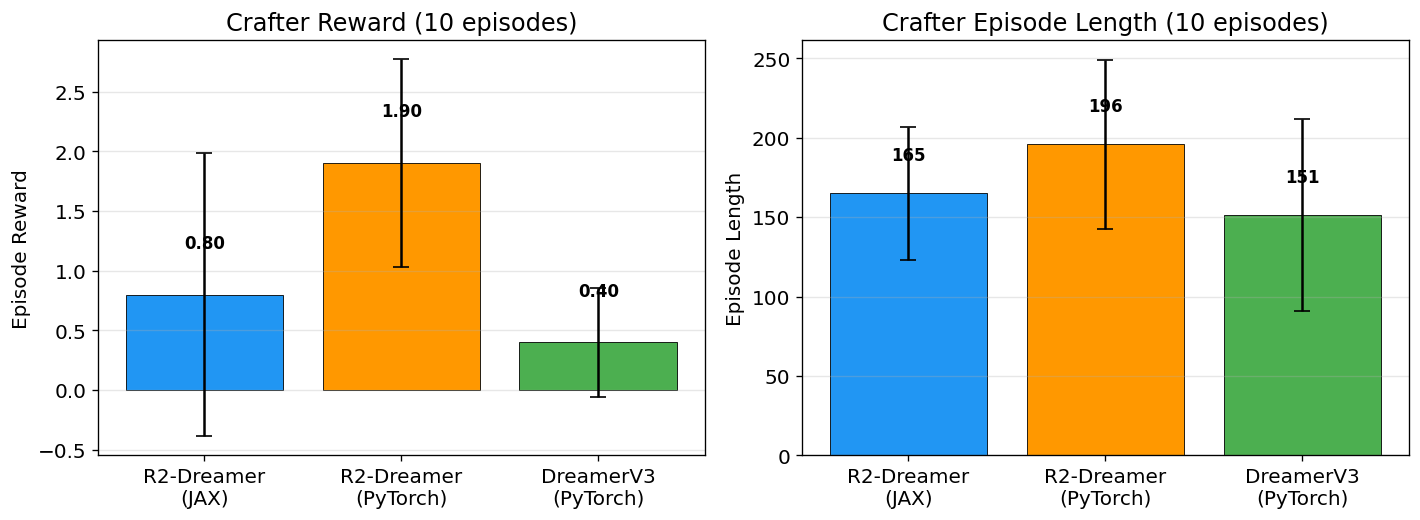

Saved: output/comparison/r2dreamer_eval_rewards.{pdf,png}

Per-episode rewards:
  JAX:     ['2.1', '2.1', '2.1', '1.1', '-0.9', '2.1', '0.1', '0.1', '-0.9', '0.1']
  R2-PT:   ['1.1', '1.1', '4.1', '2.1', '2.1', '1.1', '1.1', '2.1', '2.1', '2.1']
  DV3-PT:  ['1.1', '1.1', '0.1', '0.1', '0.1', '0.1', '1.1', '0.1', '0.1', '0.1']


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import os

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
labels = ["R2-Dreamer\n(JAX)", "R2-Dreamer\n(PyTorch)", "DreamerV3\n(PyTorch)"]
colors = ["#2196F3", "#FF9800", "#4CAF50"]

# Episode reward
ax = axes[0]
means = [np.mean(jax_rewards), np.mean(r2_pt_rewards), np.mean(dv3_pt_rewards)]
stds = [np.std(jax_rewards), np.std(r2_pt_rewards), np.std(dv3_pt_rewards)]
bars = ax.bar(labels, means, yerr=stds, color=colors, capsize=5, edgecolor="black", linewidth=0.5)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds)*0.3,
            f"{m:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Episode Reward")
ax.set_title(f"Crafter Reward ({EVAL_EPISODES} episodes)")
ax.grid(True, alpha=0.3, axis="y")

# Episode length
ax = axes[1]
means_l = [np.mean(jax_lengths), np.mean(r2_pt_lengths), np.mean(dv3_pt_lengths)]
stds_l = [np.std(jax_lengths), np.std(r2_pt_lengths), np.std(dv3_pt_lengths)]
bars = ax.bar(labels, means_l, yerr=stds_l, color=colors, capsize=5, edgecolor="black", linewidth=0.5)
for bar, m in zip(bars, means_l):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds_l)*0.3,
            f"{m:.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Episode Length")
ax.set_title(f"Crafter Episode Length ({EVAL_EPISODES} episodes)")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
fig.savefig(os.path.join(ROOT, "output", "comparison", "r2dreamer_eval_rewards.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(ROOT, "output", "comparison", "r2dreamer_eval_rewards.png"), bbox_inches="tight", dpi=200)
plt.show()
print("Saved: output/comparison/r2dreamer_eval_rewards.{pdf,png}")

# Per-episode detail
print(f"\nPer-episode rewards:")
print(f"  JAX:     {[f'{r:.1f}' for r in jax_rewards]}")
print(f"  R2-PT:   {[f'{r:.1f}' for r in r2_pt_rewards]}")
print(f"  DV3-PT:  {[f'{r:.1f}' for r in dv3_pt_rewards]}")